In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import zipfile
import os
import cv2
import glob
import random
import requests

/Users/devayushrout/Desktop/MedWaste Guardian/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [4]:
# Function to convert bounding boxes in YOLO format to xmin, ymin, xmax, ymax.
def yolo2bbox(bboxes):
    xmin, ymin = bboxes[0]-bboxes[2]/2, bboxes[1]-bboxes[3]/2
    xmax, ymax = bboxes[0]+bboxes[2]/2, bboxes[1]+bboxes[3]/2
    return xmin, ymin, xmax, ymax

In [5]:
def plot_box(image, bboxes, labels):
    # Need the image height and width to denormalize
    # the bounding box coordinates
    h, w, _ = image.shape
    for box_num, box in enumerate(bboxes):
        x1, y1, x2, y2 = yolo2bbox(box)
        # Denormalize the coordinates.
        xmin = int(x1*w)
        ymin = int(y1*h)
        xmax = int(x2*w)
        ymax = int(y2*h)

        thickness = max(2, int(w/275))
                
        cv2.rectangle(
            image, 
            (xmin, ymin), (xmax, ymax),
            color=(0, 0, 255),
            thickness=thickness
        )
    return image

In [10]:
import cv2
import os
import glob
import random
import matplotlib.pyplot as plt

# Function to plot images with bounding boxes
def plot(image_paths, label_paths, num_samples):
    all_images = []
    all_images.extend(glob.glob(os.path.join(image_paths, '*.jpg')))
    all_images.extend(glob.glob(os.path.join(image_paths, '*.JPG')))
    
    all_images.sort()
    num_images = len(all_images)
    
    plt.figure(figsize=(15, 12))
    for i in range(num_samples):
        j = random.randint(0, num_images - 1)
        image_name = all_images[j]
        image_name = os.path.splitext(os.path.basename(image_name))[0]  # Get filename without extension
        image = cv2.imread(all_images[j])

        label_file = os.path.join(label_paths, image_name + '.txt')
        if not os.path.exists(label_file):
            print(f"⚠️ Warning: Label file not found for {image_name}")
            continue

        bboxes = []
        labels = []

        with open(label_file, 'r') as f:
            label_lines = f.readlines()
            for label_line in label_lines:
                label_data = label_line.strip().split()
                
                if len(label_data) < 5:
                    print(f"⚠️ Skipping invalid label line: {label_line.strip()}")
                    continue
                
                label = int(label_data[0])  # Class label (integer)
                x_c, y_c, w, h = map(float, label_data[1:5])  # Extract bounding box values

                bboxes.append([x_c, y_c, w, h])
                labels.append(label)

        result_image = plot_box(image, bboxes, labels)
        plt.subplot(2, 2, i+1)
        plt.imshow(result_image[:, :, ::-1])
        plt.axis('off')

    plt.subplots_adjust(wspace=1)
    plt.tight_layout()
    plt.show()


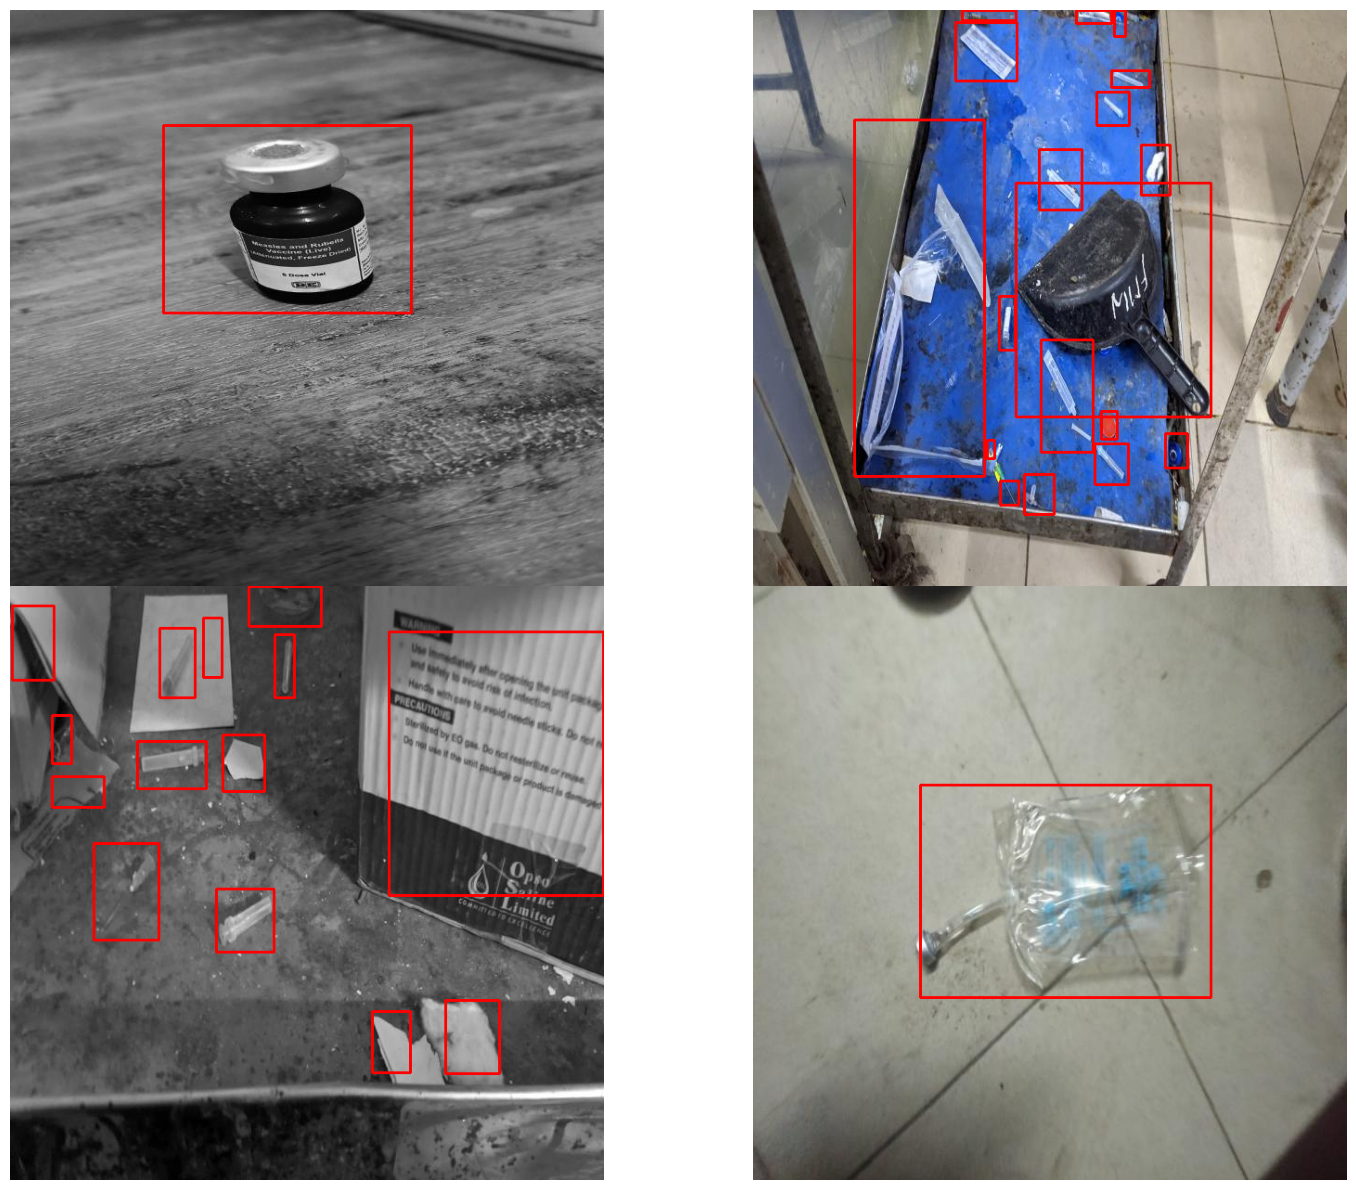

In [15]:
# Visualize a few training images.
plot(
    image_paths='dataset/train/images/', 
    label_paths='dataset/train/labels/',
    num_samples=4,
)